## Level 3 SAE features IOI task

This notebook applies the Level 3 (SAE features) analysis to the **IOI task** on GPT-2 Small,
mirroring the structure of `04_level3_sae.ipynb` used for the grokking task.

Unlike the grokking model (a single custom-trained layer), GPT-2 Small has 12 MLP layers.
We focus on **MLP layer 9**
The SAE is trained directly on that layer's post-GELU activations.

**Key methodological choices consistent with other IOI notebooks:**
- Metric: logit difference (IO logit - S logit) at the final token position
- Ablation baseline: pABC mean (encode pABC activations through SAE, take mean features)
- Corruption: inject decoded pABC-mean features at the MLP9 hook
- Patching: start from pABC-mean features, restore SAE feature *f* to its clean pIOI value

**Note on activation type**: GPT-2 uses GELU rather than ReLU, so `mlp.hook_post` activations
can be negative and are never exactly zero. The SAE encoder's bias subtraction `(x - b_dec)`
centres inputs before projection, allowing the architecture to handle negative-valued inputs.

**Expected finding**: IOI is primarily an attention-head circuit (Wang et al. 2022).
Level 2 heads achieved RS = 1.27 with just 2 / 144 heads.
Level 3 SAE features of MLP9 should show lower faithfulness and higher description length,
reflecting the weak MLP contribution to the IOI task.

In [1]:
pip install transformer_lens

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 977.7/977.7 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 113.1 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=f184f4c2a9a3db86b99e6dff5d71bf60b76c5ce3cd34fbce4b0dbb49685ad8f6
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import json
import random
from pathlib import Path
from tqdm.notebook import tqdm
from transformer_lens import HookedTransformer

torch.manual_seed(42)
random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

TARGET_LAYER = 9
D_EXPANSION  = 4      # standard 4x expansion ratio
RESULTS_DIR = Path("../results/level3IOI")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SAE_PATH   = Path(f"../data/gpt2_sae_layer{TARGET_LAYER}.pt")
SAE_PATH.parent.mkdir(parents=True, exist_ok=True)
L1_RESULTS = Path("../results/level1IOI/level1IOI_results.json")
L2_RESULTS = Path("../results/level2IOI/level2IOI_results.json")

Using device: cuda


In [3]:
model = HookedTransformer.from_pretrained(
    "gpt2",
    center_unembed=True,
    center_writing_weights=True,
    fold_ln=True,
)
# use_attn_result is NOT set here, this notebook patches mlp.hook_post only.
# Enabling it would materialize a [batch, seq, 12, 64, 768] intermediate tensor

model.eval()
model.to(device)

N_LAYERS = model.cfg.n_layers  # 12
D_MLP    = model.cfg.d_mlp     # 3072
D_SAE    = D_MLP * D_EXPANSION
print(f"Layers: {N_LAYERS}  D_MLP: {D_MLP}  D_model: {model.cfg.d_model}")
print(f"SAE: {D_MLP} -> {D_SAE} -> {D_MLP}  (expansion x{D_EXPANSION})")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cuda
Layers: 12  D_MLP: 3072  D_model: 768
SAE: 3072 -> 12288 -> 3072  (expansion x4)


## Build the IOI dataset

Identical to `02bis` and `03bis`: pIOI uses two names (IO and S); pABC uses three unrelated
names to destroy the duplication signal while preserving grammatical structure.

We generate a larger training set (N_TRAIN = 2000) so the SAE has enough activation samples
to learn meaningful sparse features, and keep N_EVAL = 200 for patching evaluation.

In [4]:
NAMES = [
    "Mary", "John", "Alice", "Bob", "Emma", "Frank", "Grace", "Henry",
    "Iris", "Jack", "Kate", "Liam", "Mia", "Noah", "Olivia", "Paul",
    "Rose", "Sam", "Tina", "Victor", "Wendy", "Anna", "Brian", "Clara",
    "Elena", "Felix", "Gina", "Harry", "Jake", "Luna", "Mark", "Nina",
    "Oscar", "Pam", "Ray", "Sara", "Tom", "Vera", "Will", "Zoe"
]
PLACES  = ["store", "school", "park", "office", "market", "gym",
           "beach", "hotel", "library", "theater", "hospital", "mall"]
OBJECTS = ["drink", "book", "ball", "bag", "gift", "key",
           "pen", "hat", "ring", "card", "toy", "cup"]

TEMPLATES = [
    "Then, [IO] and [S] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Then, [IO] and [S] had a lot of fun at the [PLACE]. [S] gave a [OBJECT] to",
    "Then, [IO] and [S] were working at the [PLACE]. [S] decided to give a [OBJECT] to",
    "Then, [IO] and [S] were thinking about going to the [PLACE]. [S] wanted to give a [OBJECT] to",
    "After [IO] and [S] went to the [PLACE], [S] gave a [OBJECT] to",
    "When [IO] and [S] got a [OBJECT] at the [PLACE], [S] decided to give it to",
    "While [IO] and [S] were working at the [PLACE], [S] gave a [OBJECT] to",
    "While [IO] and [S] were commuting to the [PLACE], [S] gave a [OBJECT] to",
    "After the lunch, [IO] and [S] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Afterwards, [IO] and [S] went to the [PLACE]. [S] gave a [OBJECT] to",
    "The [PLACE] [IO] and [S] went to had a [OBJECT]. [S] gave it to",
    "Friends [IO] and [S] found a [OBJECT] at the [PLACE]. [S] gave it to",
    "Then, [S] and [IO] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Then, [S] and [IO] had a lot of fun at the [PLACE]. [S] gave a [OBJECT] to",
    "After [S] and [IO] went to the [PLACE], [S] gave a [OBJECT] to",
    "When [S] and [IO] got a [OBJECT] at the [PLACE], [S] decided to give it to",
    "While [S] and [IO] were working at the [PLACE], [S] gave a [OBJECT] to",
    "After the lunch, [S] and [IO] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Afterwards, [S] and [IO] went to the [PLACE]. [S] gave a [OBJECT] to",
    "The [PLACE] [S] and [IO] went to had a [OBJECT]. [S] gave it to",
]

def build_dataset(N, use_abc=False, seed=42):
    rng = random.Random(seed)
    dataset = []
    for i in range(N):
        template = rng.choice(TEMPLATES)
        place    = rng.choice(PLACES)
        obj      = rng.choice(OBJECTS)
        if use_abc:
            a, b, c = rng.sample(NAMES, 3)
            prompt = (template
                        .replace("[IO]", a)
                        .replace("[S]", b, 1)
                        .replace("[S]", c)
                        .replace("[PLACE]", place)
                        .replace("[OBJECT]", obj))
            io_name, s_name = a, b
        else:
            io_name, s_name = rng.sample(NAMES, 2)
            prompt = (template
                        .replace("[IO]", io_name)
                        .replace("[S]", s_name)
                        .replace("[PLACE]", place)
                        .replace("[OBJECT]", obj))
        dataset.append({"prompt": prompt, "io": io_name, "s": s_name, "template": template})
    return dataset

N_EVAL  = 200
N_TRAIN = 2000

ioi_eval  = build_dataset(N_EVAL,  use_abc=False, seed=42)
abc_eval  = build_dataset(N_EVAL,  use_abc=True,  seed=42)
ioi_train = build_dataset(N_TRAIN, use_abc=False, seed=123)

print(f"IOI eval:  {len(ioi_eval)}")
print(f"ABC eval:  {len(abc_eval)}")
print(f"IOI train: {len(ioi_train)}")
print(f"IOI[0]: {ioi_eval[0]['prompt']!r}")


IOI eval:  200
ABC eval:  200
IOI train: 2000
IOI[0]: 'Then, Sam and Paul were thinking about going to the store. Paul wanted to give a cup to'


In [5]:
def tokenize_dataset(data, model):
    valid = []
    for ex in data:
        io_tok = model.to_tokens(" " + ex["io"], prepend_bos=False).squeeze()
        s_tok  = model.to_tokens(" " + ex["s"],  prepend_bos=False).squeeze()
        if io_tok.ndim == 0 and s_tok.ndim == 0:
            valid.append({**ex, "io_tok": io_tok.item(), "s_tok": s_tok.item()})
    return valid

def batch_tokens(valid_data, model, device):
    tokens_list = [model.to_tokens(ex["prompt"], prepend_bos=True).squeeze() for ex in valid_data]
    max_len = max(t.shape[0] for t in tokens_list)
    padded = torch.full((len(tokens_list), max_len), 50256, dtype=torch.long)
    for i, t in enumerate(tokens_list):
        padded[i, :t.shape[0]] = t
    return padded.to(device)

def get_final_positions(valid_data, model):
    seq_lens = torch.tensor(
        [model.to_tokens(ex["prompt"], prepend_bos=True).shape[-1] for ex in valid_data],
        dtype=torch.long)
    return (seq_lens - 1)

ioi_valid   = tokenize_dataset(ioi_eval,  model)
abc_valid   = tokenize_dataset(abc_eval,  model)
train_valid = tokenize_dataset(ioi_train, model)

n_valid = min(len(ioi_valid), len(abc_valid))
ioi_valid = ioi_valid[:n_valid]
abc_valid = abc_valid[:n_valid]

ioi_tokens   = batch_tokens(ioi_valid,   model, device)
abc_tokens   = batch_tokens(abc_valid,   model, device)
train_tokens = batch_tokens(train_valid, model, device)

final_positions = get_final_positions(ioi_valid, model).to(device)
train_fps       = get_final_positions(train_valid, model).to(device)

print(f"Valid examples: {n_valid}")
print(f"Train examples: {len(train_valid)}")
print(f"IOI tokens shape: {ioi_tokens.shape}")
print(f"Final pos range: [{final_positions.min()}, {final_positions.max()}]")


Valid examples: 200
Train examples: 2000
IOI tokens shape: torch.Size([200, 21])
Final pos range: [14, 20]


## Logit difference metric

Following Wang et al. 2022: metric = IO logit - S logit at the final token position.
Positive = model correctly prefers IO over S.

In [6]:
def logit_diff(logits, valid_data, fps):
    diffs = []
    for i, ex in enumerate(valid_data):
        io_logit = logits[i, fps[i].item(), ex["io_tok"]].item()
        s_logit  = logits[i, fps[i].item(), ex["s_tok"]].item()
        diffs.append(io_logit - s_logit)
    return torch.tensor(diffs)

def recovery_score(patched_metric, corrupted_metric, clean_metric):
    gap = (clean_metric - corrupted_metric).mean().item()
    if abs(gap) < 1e-8:
        return 0.0
    return (patched_metric.mean().item() - corrupted_metric.mean().item()) / gap

BATCH_SIZE = 16

all_logits = []
with torch.no_grad():
    for start in range(0, n_valid, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n_valid)
        logits = model(ioi_tokens[start:end])
        all_logits.append(logits.cpu())
        del logits
        torch.cuda.empty_cache()

baseline_logits = torch.cat(all_logits, dim=0).to(device)
clean_ld = logit_diff(baseline_logits, ioi_valid, final_positions)
print(f"Clean mean logit difference: {clean_ld.mean():.4f}  (paper reports ~3.56)")
print(f"IO predicted over S: {(clean_ld > 0).float().mean():.1%}")


Clean mean logit difference: 3.9022  (paper reports ~3.56)
IO predicted over S: 99.0%


## SAE architecture

Same architecture as in `04_level3_sae.ipynb`: encoder projects up to a larger dictionary,
ReLU enforces non-negativity and sparsity, decoder reconstructs the original activation.
The L1 penalty on feature activations drives sparsity.

**Note**: GPT-2 uses GELU (not ReLU), so `mlp.hook_post` activations can be negative.
The encoder bias subtraction `(x - b_dec)` centres inputs before projection, handling
negative-valued inputs without any modification to the standard SAE architecture.

Here D_MLP = 3072 (GPT-2 Small), D_SAE = D_MLP × D_EXPANSION.

In [7]:
class SparseAutoencoder(nn.Module):
    def __init__(self, d_in, d_sae, l1_coeff=2e-4):
        super().__init__()
        self.d_in = d_in
        self.d_sae = d_sae
        self.l1_coeff = l1_coeff

        self.W_enc = nn.Parameter(torch.empty(d_in, d_sae))
        self.b_enc = nn.Parameter(torch.zeros(d_sae))
        self.W_dec = nn.Parameter(torch.empty(d_sae, d_in))
        self.b_dec = nn.Parameter(torch.zeros(d_in))

        nn.init.kaiming_uniform_(self.W_enc)
        nn.init.kaiming_uniform_(self.W_dec)
        self._normalise_decoder()

    def _normalise_decoder(self):
        with torch.no_grad():
            self.W_dec.data = nn.functional.normalize(self.W_dec.data, dim=1)

    def encode(self, x):
        return torch.relu((x - self.b_dec) @ self.W_enc + self.b_enc)

    def decode(self, f):
        return f @ self.W_dec + self.b_dec

    def forward(self, x):
        f = self.encode(x)
        x_hat = self.decode(f)
        l2_loss = (x - x_hat).pow(2).sum(dim=-1).mean()
        l1_loss = f.abs().sum(dim=-1).mean()
        loss = l2_loss + self.l1_coeff * l1_loss
        return loss, x_hat, f, l2_loss, l1_loss


sae = SparseAutoencoder(d_in=D_MLP, d_sae=D_SAE, l1_coeff=2e-2).to(device)
print(f"SAE: {D_MLP} -> {D_SAE} -> {D_MLP}")
print(f"Parameters: {sum(p.numel() for p in sae.parameters()):,}")


SAE: 3072 -> 12288 -> 3072
Parameters: 75,512,832


## Collect MLP activations for SAE training

The SAE trains on post-GELU MLP9 activations from pIOI examples at the final token position.
We use the larger training set (N_TRAIN = 2000) so the SAE has enough examples to learn
meaningful sparse features despite GPT-2's higher-dimensional MLP (3072 vs 512 in grokking).

Note: GELU activations can be negative (mean around 0) and are never exactly zero, unlike the
grokking model's ReLU activations.

In [8]:
HOOK = f"blocks.{TARGET_LAYER}.mlp.hook_post"

print(f"Collecting MLP{TARGET_LAYER} activations from pIOI training set ({len(train_valid)} examples)...")
all_mlp_acts = []
with torch.no_grad():
    for i in tqdm(range(0, len(train_valid), 64)):
        batch    = train_tokens[i:i+64]
        batch_fp = train_fps[i:i+64]
        _, cache = model.run_with_cache(batch, names_filter=HOOK)
        acts = cache[HOOK]  # [batch, seq, d_mlp]
        bi   = torch.arange(acts.shape[0], device=device)
        all_mlp_acts.append(acts[bi, batch_fp].cpu())
        del cache, acts
        torch.cuda.empty_cache()

mlp_acts_train = torch.cat(all_mlp_acts, dim=0)  # [N_train, D_MLP]
print(f"Training activations shape: {mlp_acts_train.shape}")
print(f"Mean activation: {mlp_acts_train.mean():.4f}")
print(f"Fraction zero (sparsity): {(mlp_acts_train == 0).float().mean():.4f}")


  0%|          | 0/32 [00:00<?, ?it/s]

Training activations shape: torch.Size([2000, 3072])
Mean activation: -0.0429
Fraction zero (sparsity): 0.0000


## Train the SAE

First run trains and saves the SAE. Subsequent runs load from disk.


In [9]:
if SAE_PATH.exists():
    sae.load_state_dict(torch.load(SAE_PATH, map_location=device))
    sae.to(device).eval()
    print(f"Loaded saved SAE from {SAE_PATH}")
else:
    print("Training SAE...")
    sae_optimizer = optim.Adam(sae.parameters(), lr=2e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        sae_optimizer, T_max=20_000, eta_min=1e-5)
    sae.train()

    N_STEPS = 20_000
    BATCH   = 256

    for step in tqdm(range(N_STEPS)):
        idx = torch.randint(0, len(mlp_acts_train), (BATCH,))
        x   = mlp_acts_train[idx].to(device)
        loss, _, _, l2, l1 = sae(x)
        sae_optimizer.zero_grad()
        loss.backward()
        sae_optimizer.step()
        scheduler.step()
        sae._normalise_decoder()

        if (step + 1) % 5_000 == 0:
            print(f"step {step+1}  loss={loss.item():.4f}  l2={l2.item():.4f}  l1={l1.item():.4f}")

    sae.eval()
    torch.save(sae.state_dict(), SAE_PATH)
    print(f"SAE saved to {SAE_PATH}")

Training SAE...


  0%|          | 0/20000 [00:00<?, ?it/s]

step 5000  loss=1.4316  l2=0.4823  l1=47.4673
step 10000  loss=0.7095  l2=0.0553  l1=32.7097
step 15000  loss=0.5097  l2=0.0183  l1=24.5660
step 20000  loss=0.4590  l2=0.0115  l1=22.3736
SAE saved to ../data/gpt2_sae_layer9.pt


## Evaluate SAE reconstruction quality

Before trusting the SAE features we verify reconstruction quality.
Fraction of variance explained should be > 0.90 and mean active features should be
well below D_SAE.

In [10]:
sae.eval()

with torch.no_grad():
    x_check     = mlp_acts_train[:1000].to(device)
    feat_check  = sae.encode(x_check)
    recon_check = sae.decode(feat_check)

l2_err   = (x_check - recon_check).pow(2).sum(-1).mean().item()
var_exp  = 1 - (x_check - recon_check).pow(2).sum() / x_check.pow(2).sum()
n_active = (feat_check > 0).float().sum(-1).mean().item()

print(f"Reconstruction L2 error:         {l2_err:.4f}")
print(f"Variance explained:              {var_exp:.4f}  (target > 0.90)")
print(f"Mean active features per input:  {n_active:.1f} / {D_SAE}")
print(f"Average sparsity:                {1 - n_active/D_SAE:.4f}")


Reconstruction L2 error:         0.0119
Variance explained:              0.9999  (target > 0.90)
Mean active features per input:  134.8 / 12288
Average sparsity:                0.9890


## pABC mean feature activations (ablation baseline)

Following the IOI paper convention, we use pABC activations as the ablation baseline.
We encode the pABC MLP9 activations through the SAE and take their mean as
the corrupted feature representation: this removes the IO/S duplication signal
while preserving grammatical structure.

In [11]:
print(f"Collecting MLP{TARGET_LAYER} activations from pABC eval set...")
abc_mlp_acts = []
with torch.no_grad():
    for start in range(0, n_valid, BATCH_SIZE):
        end      = min(start + BATCH_SIZE, n_valid)
        batch    = abc_tokens[start:end]
        batch_fp = final_positions[start:end]
        _, cache = model.run_with_cache(batch, names_filter=HOOK)
        acts = cache[HOOK]
        bi   = torch.arange(acts.shape[0], device=device)
        abc_mlp_acts.append(acts[bi, batch_fp].cpu())
        del cache, acts
        torch.cuda.empty_cache()

abc_mlp_acts = torch.cat(abc_mlp_acts, dim=0).to(device)  # [n_valid, D_MLP]

with torch.no_grad():
    abc_feat_acts = sae.encode(abc_mlp_acts)  # [n_valid, D_SAE]

mean_abc_feats = abc_feat_acts.mean(dim=0)  # [D_SAE]
print(f"pABC mean feature activations shape: {mean_abc_feats.shape}")
print(f"Non-zero mean pABC features: {(mean_abc_feats > 0).sum().item()}")

print(f"\nCollecting clean pIOI MLP{TARGET_LAYER} activations for eval set...")
clean_mlp_acts = []
with torch.no_grad():
    for start in range(0, n_valid, BATCH_SIZE):
        end      = min(start + BATCH_SIZE, n_valid)
        batch    = ioi_tokens[start:end]
        batch_fp = final_positions[start:end]
        _, cache = model.run_with_cache(batch, names_filter=HOOK)
        acts = cache[HOOK]
        bi   = torch.arange(acts.shape[0], device=device)
        clean_mlp_acts.append(acts[bi, batch_fp].cpu())
        del cache, acts
        torch.cuda.empty_cache()

clean_mlp_eval = torch.cat(clean_mlp_acts, dim=0).to(device)  # [n_valid, D_MLP]

with torch.no_grad():
    clean_feats_eval = sae.encode(clean_mlp_eval)  # [n_valid, D_SAE]

print(f"Clean features shape: {clean_feats_eval.shape}")
print(f"Mean active clean features: {(clean_feats_eval > 0).float().sum(-1).mean():.1f}")


pABC mean feature activations shape: torch.Size([12288])
Non-zero mean pABC features: 11120

Clean features shape: torch.Size([200, 12288])
Mean active clean features: 199.2


## Clean and corrupted baselines

**Corrupted**: inject decoded pABC-mean features at the MLP3 hook. This replaces the
task-specific MLP3 output with the baseline pABC output, establishing the floor LD.

**Clean**: normal pIOI forward pass (already computed above as `clean_ld`).

The gap (clean - corrupted) is what individual SAE features will be scored against.

In [12]:
mean_f = mean_abc_feats.to(device)  # [D_SAE]

with torch.no_grad():
    corrupted_recon = sae.decode(mean_f.unsqueeze(0)).squeeze(0)  # [D_MLP]

all_corrupted_ld = []
with torch.no_grad():
    for start in range(0, n_valid, BATCH_SIZE):
        end       = min(start + BATCH_SIZE, n_valid)
        batch_fps = final_positions[start:end]
        cr        = corrupted_recon

        def corrupt_hook(value, hook, fp=batch_fps, cr=cr):
            bi = torch.arange(value.shape[0], device=value.device)
            value[bi, fp] = cr.unsqueeze(0).expand(value.shape[0], -1)
            return value

        logits = model.run_with_hooks(ioi_tokens[start:end], fwd_hooks=[(HOOK, corrupt_hook)])
        all_corrupted_ld.append(logit_diff(logits.cpu(), ioi_valid[start:end], batch_fps.cpu()))
        del logits
        torch.cuda.empty_cache()

corrupted_ld = torch.cat(all_corrupted_ld)

print(f"Clean metric (mean LD):     {clean_ld.mean():.4f}")
print(f"Corrupted metric (mean LD): {corrupted_ld.mean():.4f}")
print(f"Gap to recover:             {(clean_ld - corrupted_ld).mean():.4f}")


Clean metric (mean LD):     3.9022
Corrupted metric (mean LD): 3.3950
Gap to recover:             0.5072


## SAE feature scoring, gradient-based direct effect

With D_SAE = 12,288 features, exact per-feature patching would require too many forward passes. Instead we use the **gradient * activation** approximation as in previous notebooks:


The scores are used to rank features for the greedy circuit.
The greedy circuit itself (next cell) measures joint faithfulness with exact activation
patching, so the final reported RS is not approximate.

In [13]:
grads_all = []
for start in tqdm(range(0, n_valid, BATCH_SIZE), desc="Gradient passes"):
    end       = min(start + BATCH_SIZE, n_valid)
    batch_fps = final_positions[start:end]
    captured  = {}

    def cap_hook(value, hook):
        v = value.detach().requires_grad_(True)
        captured['v'] = v
        return v

    logits = model.run_with_hooks(ioi_tokens[start:end], fwd_hooks=[(HOOK, cap_hook)])
    ld = torch.stack([
        logits[i, batch_fps[i], ex["io_tok"]] - logits[i, batch_fps[i], ex["s_tok"]]
        for i, ex in enumerate(ioi_valid[start:end])
    ])
    ld.sum().backward()
    bi = torch.arange(end - start)
    grads_all.append(captured['v'].grad[bi, batch_fps].detach().cpu())  # [N, D_MLP]
    del logits
    torch.cuda.empty_cache()

grad_ld = torch.cat(grads_all)  # [n_valid, D_MLP]

# approx_RS[f] = mean_n [ delta[n,f] * (grad[n] · W_dec[f]) ] / gap
delta  = (clean_feats_eval - mean_f.unsqueeze(0)).cpu()  # [n_valid, D_SAE]
eff_g  = grad_ld @ sae.W_dec.detach().T.cpu()            # [n_valid, D_SAE]  detach W_dec
gap    = (clean_ld - corrupted_ld).mean().item()
scores = (eff_g * delta).mean(0) / gap                   # [D_SAE], no grad

print(f"Max approx RS: {scores.max():.4f}")
print(f"Features with approx RS > 0.01: {(scores > 0.01).sum().item()}")
print(f"Features with approx RS > 0.10: {(scores > 0.10).sum().item()}")

Gradient passes:   0%|          | 0/13 [00:00<?, ?it/s]

Max approx RS: 0.0302
Features with approx RS > 0.01: 55
Features with approx RS > 0.10: 0


## Sanity check, full restore RS

Before running the greedy circuit, verify that restoring all SAE features achieves
RS around 1.0. This confirms the SAE reconstruction is faithful enough to trust per-feature
attribution. If full-restore RS < 0.95, retrain the SAE before proceeding.

In [14]:
all_feats_ld = []
with torch.no_grad():
    for start in range(0, n_valid, BATCH_SIZE):
        end         = min(start + BATCH_SIZE, n_valid)
        batch_fps_c = final_positions[start:end]
        cfe         = clean_feats_eval[start:end].to(device)

        def all_feat_hook(value, hook, fp=batch_fps_c, cfe_=cfe):
            bi = torch.arange(value.shape[0], device=value.device)
            value[bi, fp] = sae.decode(cfe_)
            return value

        logits = model.run_with_hooks(ioi_tokens[start:end], fwd_hooks=[(HOOK, all_feat_hook)])
        all_feats_ld.append(logit_diff(logits.cpu(), ioi_valid[start:end], batch_fps_c.cpu()))
        del logits
        torch.cuda.empty_cache()

full_restore_rs = recovery_score(torch.cat(all_feats_ld), corrupted_ld, clean_ld)
print(f"Full restore (all features) RS : {full_restore_rs:.4f}  (target ≈ 1.0)")
print(f"Variance explained             : {var_exp:.4f}")
print()
if full_restore_rs < 0.95:
    print("WARNING: full-restore RS < 0.95. SAE is too lossy — retrain before trusting feature RS values.")
else:
    print("Sanity check passed: feature attribution is trustworthy.")

Full restore (all features) RS : 0.9678  (target ≈ 1.0)
Variance explained             : 0.9999

Sanity check passed: feature attribution is trustworthy.


## Criterion 1 (Faithfulness) and Criterion 2 (Description length) greedy circuit

Mirrors `04_level3_sae.ipynb`, `03bis`, and `02bis`: add features greedily by gradient RS
rank until joint faithfulness ≥ RS_TARGET = 0.90.

**Implementation notes for IOI Level 3:**
- `MAX_STEPS = 500` caps the loop. If RS_TARGET is not reached, we report the
  **best RS achieved** and the corresponding description length.
- Non-monotonicity is possible: gradient scores are an approximation, and when individual
  effects are around 0.01 RS units (IOI MLP3 gap = 0.335), some nominally positive-score features
  have negative exact RS.

Building greedy circuit (target RS ≥ 0.9, max 500 steps)...


Greedy steps:   0%|          | 0/500 [00:00<?, ?it/s]

  k=  50  RS=0.2163  best=0.2163
  k= 100  RS=0.3526  best=0.3536
  k= 150  RS=0.4853  best=0.4875
  k= 200  RS=0.6033  best=0.6033
  k= 250  RS=0.7118  best=0.7118
  k= 300  RS=0.8135  best=0.8135
  k= 338  RS=0.9006  best=0.9006

  Level 3 — SAE features (IOI, MLP9)
  RS target            : 0.9
  Target reached       : True
  Max individual RS    : 0.0302
  Full restore RS      : 0.9678
  Criterion 1  Faithfulness RS    : 0.9006
  Criterion 2  Description length : 0.0275  (338 / 12288 features)


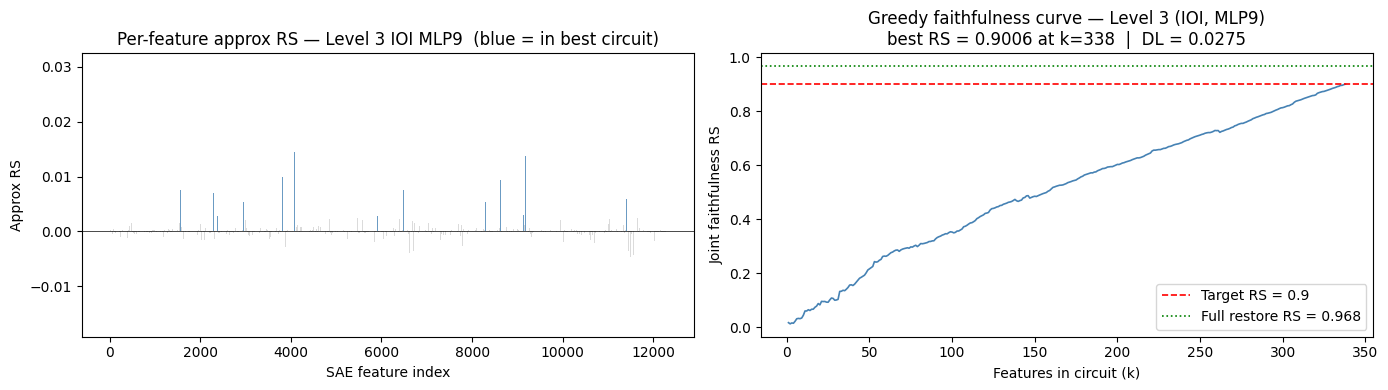

In [15]:
RS_TARGET  = 0.90
MAX_STEPS  = 500          # cap
PATCH_BATCH = n_valid     # all examples in one pass

sorted_scores, sorted_idx = scores.sort(descending=True)
pos_feats = sorted_idx[sorted_scores > 0].tolist()

circuit_features  = []
best_faithfulness = 0.0
best_k            = 0
faithfulness      = 0.0
rs_curve          = []

print(f"Building greedy circuit (target RS ≥ {RS_TARGET}, max {MAX_STEPS} steps)...")
for step, feat in enumerate(tqdm(pos_feats[:MAX_STEPS], desc="Greedy steps")):
    circuit_features.append(feat)
    cf  = list(circuit_features)
    cfe = clean_feats_eval.to(device)           # [n_valid, D_SAE]
    fp  = final_positions                        # [n_valid]

    def circuit_hook(value, hook, fp_=fp, cfe_=cfe, cf_=cf):
        bs      = value.shape[0]
        patched = mean_f.unsqueeze(0).expand(bs, -1).clone()
        for f in cf_:
            patched[:, f] = cfe_[:, f]
        bi = torch.arange(bs, device=value.device)
        value[bi, fp_] = sae.decode(patched)
        return value

    with torch.no_grad():
        logits = model.run_with_hooks(ioi_tokens, fwd_hooks=[(HOOK, circuit_hook)])
    faithfulness = recovery_score(
        logit_diff(logits.cpu(), ioi_valid, fp.cpu()), corrupted_ld, clean_ld)
    rs_curve.append(faithfulness)
    del logits
    torch.cuda.empty_cache()

    if faithfulness > best_faithfulness:
        best_faithfulness = faithfulness
        best_k            = len(circuit_features)

    k = len(circuit_features)
    if k % 50 == 0 or faithfulness >= RS_TARGET or k == len(pos_feats[:MAX_STEPS]):
        print(f"  k={k:4d}  RS={faithfulness:.4f}  best={best_faithfulness:.4f}")
    if faithfulness >= RS_TARGET:
        break

n_circuit_features = best_k
description_length = n_circuit_features / D_SAE
target_reached     = best_faithfulness >= RS_TARGET

print()
print("=" * 60)
print(f"  Level 3 — SAE features (IOI, MLP{TARGET_LAYER})")
print("=" * 60)
print(f"  RS target            : {RS_TARGET}")
print(f"  Target reached       : {target_reached}")
print(f"  Max individual RS    : {scores.max():.4f}")
print(f"  Full restore RS      : {full_restore_rs:.4f}")
print(f"  Criterion 1  Faithfulness RS    : {best_faithfulness:.4f}"
      + ("" if target_reached else f"  (best in {MAX_STEPS} steps)"))
print(f"  Criterion 2  Description length : {description_length:.4f}  "
      f"({n_circuit_features} / {D_SAE} features)")
print("=" * 60)

in_circuit_set = set(circuit_features[:best_k])
scores_np = scores.detach().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

colors = ["steelblue" if i in in_circuit_set else "lightgray" for i in range(D_SAE)]
ax1.bar(range(D_SAE), scores_np, color=colors, alpha=0.8)
ax1.axhline(0, color="black", linewidth=0.5)
ax1.set_xlabel("SAE feature index")
ax1.set_ylabel("Approx RS")
ax1.set_title(f"Per-feature approx RS — Level 3 IOI MLP{TARGET_LAYER}  (blue = in best circuit)")

ax2.plot(range(1, len(rs_curve) + 1), rs_curve, color="steelblue", linewidth=1.2)
ax2.axhline(RS_TARGET, color="red", linestyle="--", linewidth=1.2, label=f"Target RS = {RS_TARGET}")
ax2.axhline(full_restore_rs, color="green", linestyle=":", linewidth=1.2,
            label=f"Full restore RS = {full_restore_rs:.3f}")
ax2.set_xlabel("Features in circuit (k)")
ax2.set_ylabel("Joint faithfulness RS")
ax2.set_title(f"Greedy faithfulness curve — Level 3 (IOI, MLP{TARGET_LAYER})\n"
              f"best RS = {best_faithfulness:.4f} at k={best_k}  |  DL = {description_length:.4f}")
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "level3IOI_recovery_scores.png", dpi=150)
plt.show()

## Three-level comparison table (IOI task)

In [16]:
with open(L1_RESULTS) as f:
    l1 = json.load(f)
with open(L2_RESULTS) as f:
    l2 = json.load(f)

print("=" * 65)
print("  IOI task - three-level comparison")
print("=" * 65)
print(f"{'':25s}  {'Level 1':>10s}  {'Level 2':>10s}  {'Level 3':>10s}")
print(f"{'':25s}  {'neurons':>10s}  {'att. heads':>10s}  {'SAE feats':>10s}")
print("=" * 65)
print(f"{'Faithfulness RS':25s}  "
      f"{l1['criterion1_faithfulness']:>10.4f}  "
      f"{l2['criterion1_faithfulness']:>10.4f}  "
      f"{best_faithfulness:>10.4f}")
print(f"{'Circuit components':25s}  "
      f"{l1['criterion2_circuit_neurons']:>10d}  "
      f"{l2['criterion2_circuit_heads']:>10d}  "
      f"{n_circuit_features:>10d}")
print(f"{'Total components':25s}  "
      f"{l1['criterion2_total_neurons']:>10d}  "
      f"{l2['criterion2_total_heads']:>10d}  "
      f"{D_SAE:>10d}")
print(f"{'Description length':25s}  "
      f"{l1['criterion2_description_length']:>10.4f}  "
      f"{l2['criterion2_description_length']:>10.4f}  "
      f"{description_length:>10.4f}")
print(f"{'Circuit selection':25s}  "
      f"{'RS≥0.90':>10s}  "
      f"{'RS≥0.90':>10s}  "
      + (f"{'RS≥0.90':>10s}" if target_reached else f"{'best in 500':>10s}"))
print("=" * 65)
if not target_reached:
    print(f"\nNote: RS target not reached. Full restore RS = {full_restore_rs:.4f}.")

FileNotFoundError: [Errno 2] No such file or directory: '../results/level1IOI/level1IOI_results.json'

## Save results

In [17]:
results = {
    "level": 3,
    "task": "ioi",
    "method": "sae_feature_patching",
    "target_layer": TARGET_LAYER,
    "d_in": D_MLP,
    "d_sae": D_SAE,
    "n_eval": n_valid,
    "n_train": len(train_valid),
    "sae_variance_explained": var_exp.item(),
    "sae_mean_active_features": n_active,
    "clean_ld_mean": clean_ld.mean().item(),
    "corrupted_ld_mean": corrupted_ld.mean().item(),
    "gap": (clean_ld - corrupted_ld).mean().item(),
    "full_restore_rs": full_restore_rs,
    "circuit_selection": "greedy_cumulative",
    "rs_target": RS_TARGET,
    "rs_target_reached": target_reached,
    "max_steps": MAX_STEPS,
    "max_individual_rs": scores.max().item(),
    "criterion1_faithfulness": best_faithfulness,
    "criterion2_description_length": description_length,
    "criterion2_circuit_features": n_circuit_features,
    "criterion2_total_features": D_SAE,
    "circuit_features": circuit_features[:best_k],
    "all_recovery_scores": scores.tolist(),
}

with open(RESULTS_DIR / "level3IOI_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {RESULTS_DIR}/level3IOI_results.json")

Results saved to ../results/level3IOI/level3IOI_results.json


## Top feature analysis (tentative)

Unlike the grokking case where top SAE features encode Fourier frequencies, we expect
IOI's top MLP3 features to reflect more diffuse or grammatical properties rather than
the structured IO-duplication signal (which lives in attention heads, per Level 2 results).

We inspect each top feature's pIOI vs pABC mean activation and its firing rate to
characterise what the feature is sensitive to.

Top 10 SAE features of MLP9 by individual recovery score:
Rank   Feature        RS   Mean pABC act   Mean pIOI act   % pIOI active
   1     11989    0.0302          0.2858          0.0079           7.0%
   2       324    0.0296          0.4446          0.0027           3.5%
   3       439    0.0294          0.2143          0.0021           1.5%
   4      1987    0.0284          0.1831          0.0050           1.0%
   5      5811    0.0281          0.2313          0.0042           4.5%
   6      4747    0.0256          0.2778          0.0020           0.5%
   7     12156    0.0247          0.3654          0.0245           5.0%
   8      8913    0.0207          0.1395          0.0033           2.0%
   9     11466    0.0204          0.2773          0.0000           0.0%
  10      7980    0.0182          0.1854          0.0006           2.5%


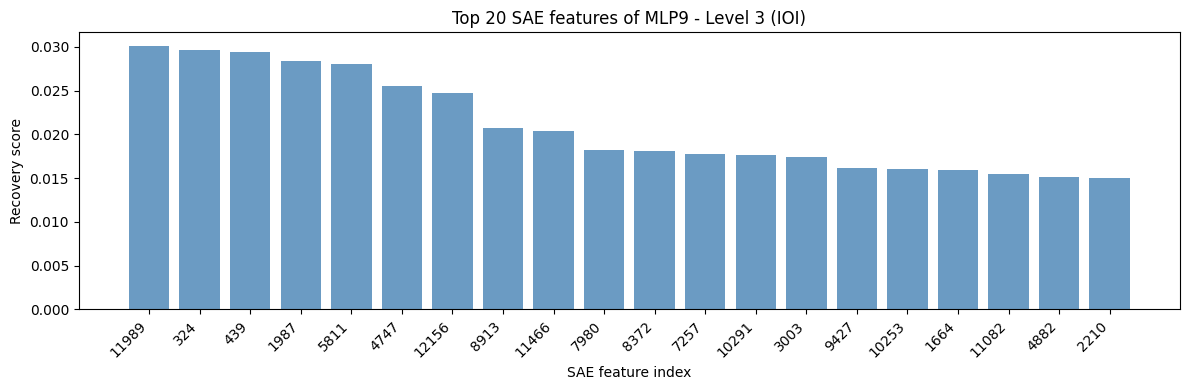

In [18]:
top10_scores, top10_idx = scores.topk(10)

print(f"Top 10 SAE features of MLP{TARGET_LAYER} by individual recovery score:")
print(f"{'Rank':>4}  {'Feature':>8}  {'RS':>8}  "
      f"{'Mean pABC act':>14}  {'Mean pIOI act':>14}  {'% pIOI active':>14}")
for rank, (score, fidx) in enumerate(zip(top10_scores, top10_idx)):
    fidx       = fidx.item()
    mean_abc_a = mean_abc_feats[fidx].item()
    mean_ioi_a = clean_feats_eval[:, fidx].mean().item()
    pct_act    = (clean_feats_eval[:, fidx] > 0).float().mean().item()
    print(f"{rank+1:>4}  {fidx:>8}  {score.item():>8.4f}  "
          f"{mean_abc_a:>14.4f}  {mean_ioi_a:>14.4f}  {pct_act:>13.1%}")

top20_scores, top20_idx = scores.topk(20)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(20), top20_scores.detach().numpy(), color="steelblue", alpha=0.8)
ax.set_xticks(range(20))
ax.set_xticklabels([str(i.item()) for i in top20_idx], rotation=45, ha="right")
ax.set_xlabel("SAE feature index")
ax.set_ylabel("Recovery score")
ax.set_title(f"Top 20 SAE features of MLP{TARGET_LAYER} - Level 3 (IOI)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "level3IOI_top_features.png", dpi=150)
plt.show()